# Irrigation Need Prediction

This notebook predicts whether a field has **Low**, **Medium**, or **High** irrigation need using soil, weather, crop, and field-management variables.

## 1. Setup

Import the libraries used for analysis, preprocessing, modeling, and evaluation.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

## 2. Load the Dataset

Read the local copy of the Kaggle irrigation water requirement dataset.

In [2]:
DATA_PATH = 'data/irrigation_prediction.csv'

irrigation_df = pd.read_csv(DATA_PATH)
irrigation_df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,Yes,34.62,South,Low
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Canal,Reservoir,1.43,Yes,84.03,North,Medium
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,Canal,River,2.52,No,60.86,South,Medium


## 3. Data Audit

Check the size, schema, missing values, and class distribution.

In [3]:
print(f'Dataset shape: {irrigation_df.shape}')
print('Columns:')
print(irrigation_df.columns.tolist())

Dataset shape: (10000, 20)
Columns:
['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need']


In [4]:
missing_values = irrigation_df.isna().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [5]:
irrigation_df.describe(include='all')

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
count,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000,10000,10000,10000,10000,10000.000000,10000,10000.000000,10000,10000
unique,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,4,3,4,4,NaN,2,NaN,5,3
top,Sandy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Rice,Harvest,Rabi,Sprinkler,River,NaN,No,NaN,South,Low
freq,2536,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1711,2581,3383,2527,2528,NaN,5013,NaN,2102,5864
mean,NaN,6.487857,36.969207,0.944731,1.791963,26.991423,60.080339,1252.499420,7.518538,10.163545,NaN,NaN,NaN,NaN,NaN,7.598024,NaN,59.864122,NaN,NaN
std,NaN,0.979963,16.430845,0.372406,0.984202,8.664074,20.187973,715.582201,2.016077,5.670923,NaN,NaN,NaN,NaN,NaN,4.233919,NaN,34.483722,NaN,NaN
min,NaN,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,NaN,NaN,NaN,NaN,NaN,0.300000,NaN,0.020000,NaN,NaN
25%,NaN,5.640000,22.860000,0.620000,0.940000,19.460000,42.855000,634.155000,5.760000,5.160000,NaN,NaN,NaN,NaN,NaN,3.950000,NaN,30.160000,NaN,NaN
50%,NaN,6.470000,37.240000,0.950000,1.780000,27.090000,60.040000,1250.335000,7.560000,10.190000,NaN,NaN,NaN,NaN,NaN,7.540000,NaN,59.630000,NaN,NaN
75%,NaN,7.350000,50.940000,1.260000,2.650000,34.500000,77.705000,1880.265000,9.260000,15.100000,NaN,NaN,NaN,NaN,NaN,11.202500,NaN,90.030000,NaN,NaN


In [6]:
target_column = 'Irrigation_Need'
class_distribution = irrigation_df[target_column].value_counts()
class_distribution

Irrigation_Need
Low       5864
Medium    3800
High       336
Name: count, dtype: int64

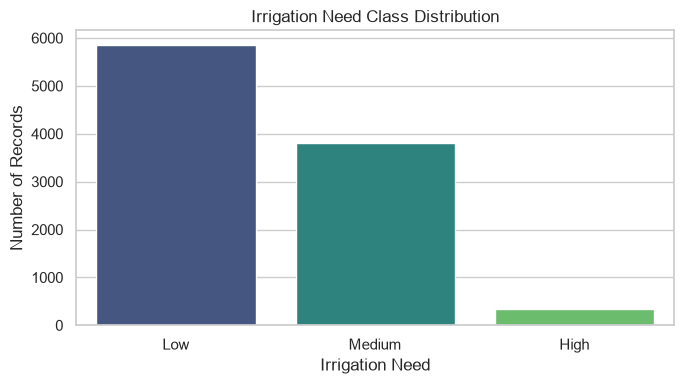

In [7]:
plt.figure(figsize=(7, 4))
sns.barplot(x=class_distribution.index, y=class_distribution.values, palette='viridis')
plt.title('Irrigation Need Class Distribution')
plt.xlabel('Irrigation Need')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

## 4. Feature Overview

Separate numeric and categorical predictors for analysis and preprocessing.

In [8]:
categorical_features = irrigation_df.drop(columns=[target_column]).select_dtypes(include='object').columns.tolist()
numeric_features = irrigation_df.drop(columns=[target_column]).select_dtypes(exclude='object').columns.tolist()

print(f'Numeric features ({len(numeric_features)}): {numeric_features}')
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')

Numeric features (11): ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']
Categorical features (8): ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']


## 5. Exploratory Analysis

Review numeric distributions and categorical relationships with irrigation need.

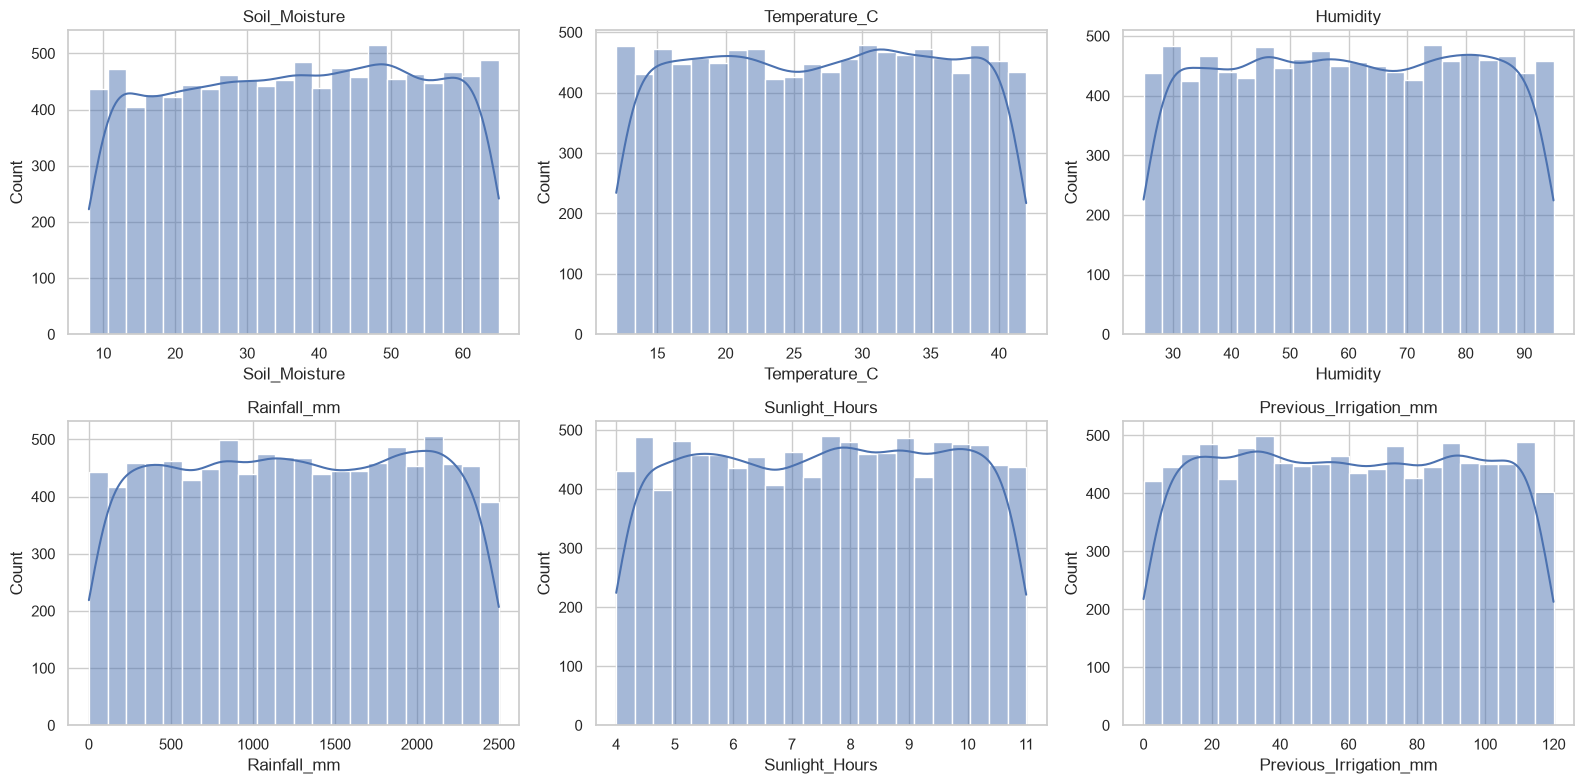

In [9]:
selected_numeric_features = [
    'Soil_Moisture',
    'Temperature_C',
    'Humidity',
    'Rainfall_mm',
    'Sunlight_Hours',
    'Previous_Irrigation_mm',
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for axis, feature in zip(axes, selected_numeric_features):
    sns.histplot(irrigation_df[feature], kde=True, ax=axis)
    axis.set_title(feature)

plt.tight_layout()
plt.show()

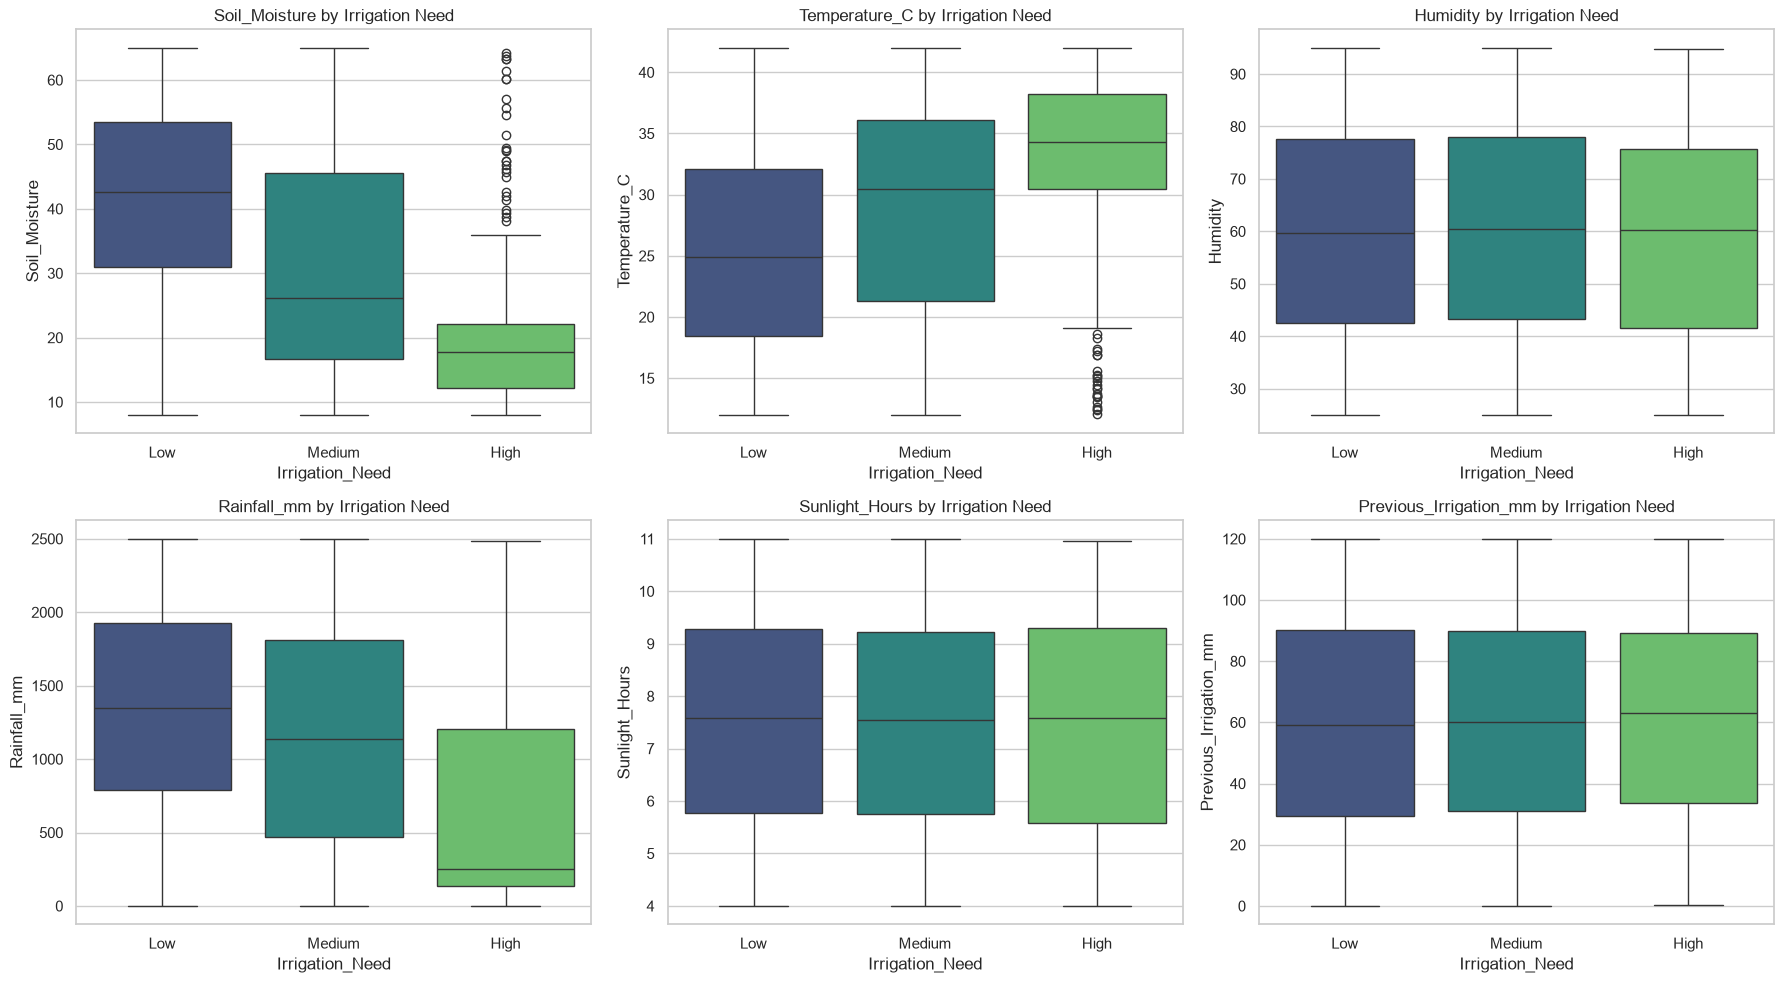

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for axis, feature in zip(axes, selected_numeric_features):
    sns.boxplot(data=irrigation_df, x=target_column, y=feature, ax=axis, palette='viridis')
    axis.set_title(f'{feature} by Irrigation Need')

plt.tight_layout()
plt.show()

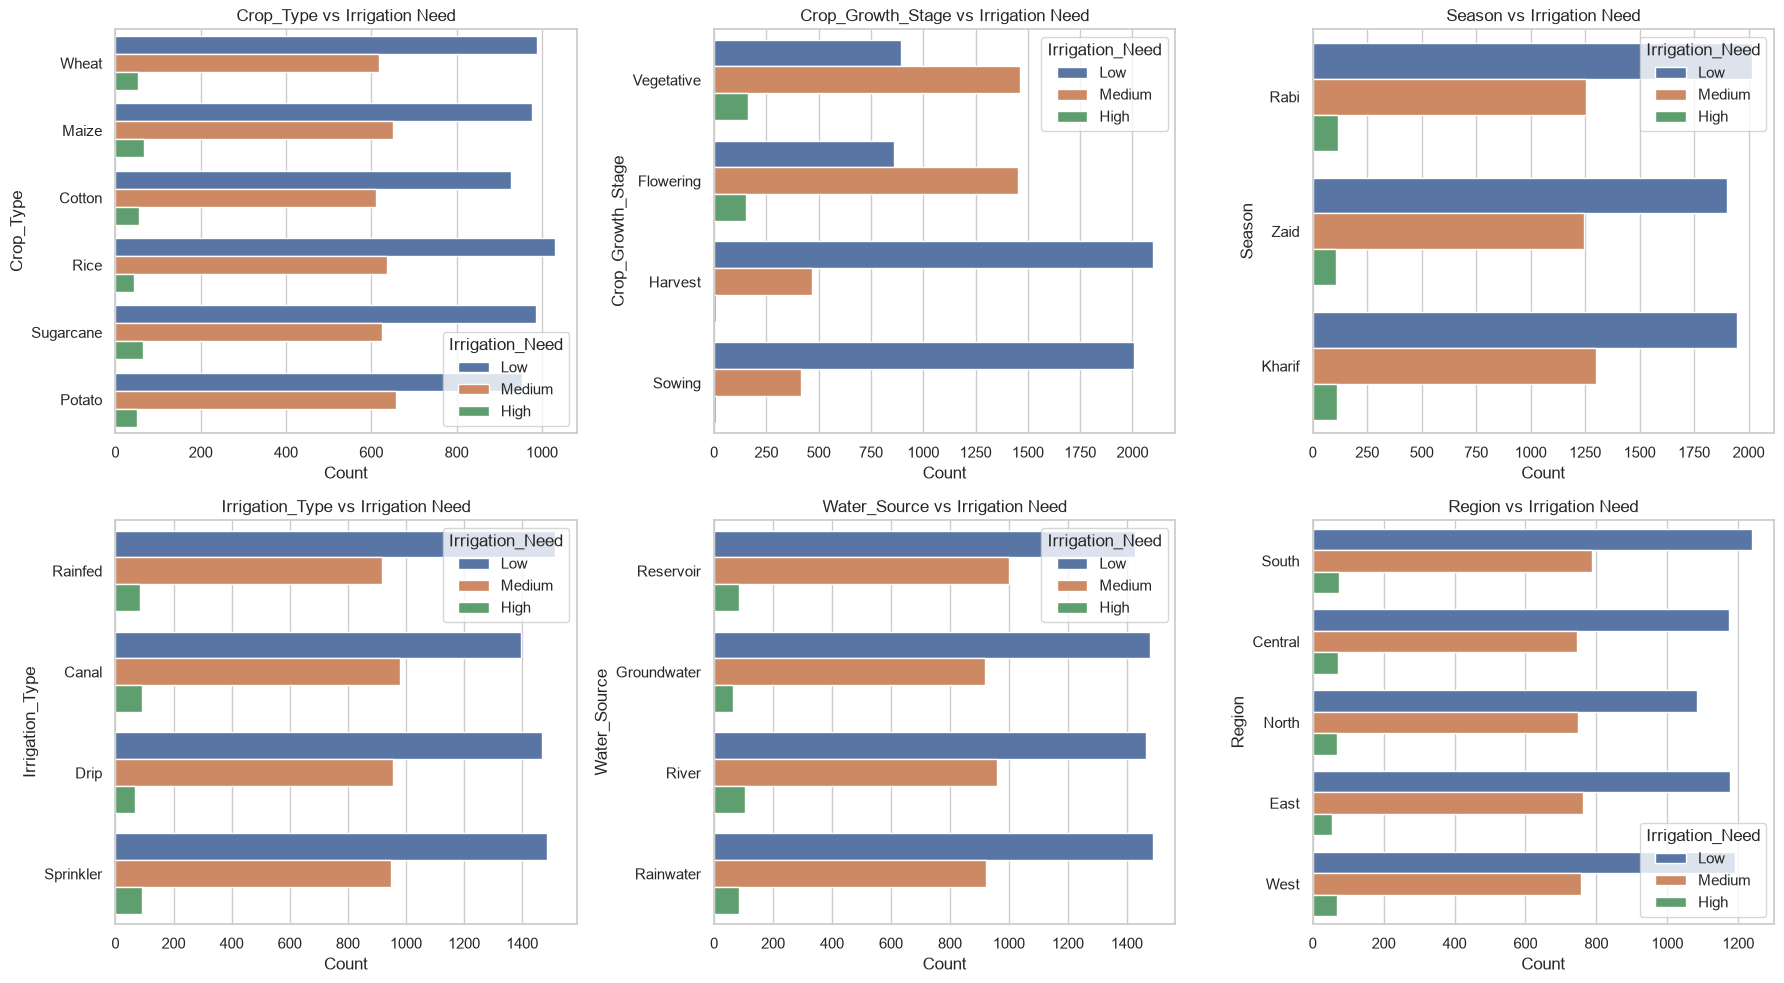

In [11]:
selected_categorical_features = ['Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Region']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for axis, feature in zip(axes, selected_categorical_features):
    sns.countplot(data=irrigation_df, y=feature, hue=target_column, ax=axis)
    axis.set_title(f'{feature} vs Irrigation Need')
    axis.set_xlabel('Count')
    axis.set_ylabel(feature)

plt.tight_layout()
plt.show()

## 6. Preprocessing and Train/Test Split

Use a consistent preprocessing pipeline: scale numeric variables and one-hot encode categorical variables. Stratification preserves the class distribution across train and test sets.

In [12]:
model_features = irrigation_df.drop(columns=[target_column])
irrigation_labels = irrigation_df[target_column]

training_features, test_features, training_labels, test_labels = train_test_split(
    model_features,
    irrigation_labels,
    test_size=0.2,
    random_state=42,
    stratify=irrigation_labels,
)

preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', StandardScaler(), numeric_features),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

print(f'training_features shape: {training_features.shape}')
print(f'test_features shape: {test_features.shape}')

training_features shape: (8000, 19)
test_features shape: (2000, 19)


## 7. Model Comparison

Compare several classifiers. Because `High` irrigation need is rare, macro F1 is used as the primary ranking metric, with accuracy as a secondary metric.

In [13]:
candidate_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=300, class_weight='balanced', random_state=42),
    'LightGBM': LGBMClassifier(random_state=42, class_weight='balanced', verbosity=-1),
    'CatBoost': CatBoostClassifier(random_seed=42, verbose=False, auto_class_weights='Balanced', allow_writing_files=False),
}

model_results = []
trained_pipelines = {}
test_predictions = {}

for model_name, classifier in candidate_models.items():
    model_pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('classifier', classifier),
        ]
    )
    model_pipeline.fit(training_features, training_labels)
    predicted_labels = model_pipeline.predict(test_features)

    trained_pipelines[model_name] = model_pipeline
    test_predictions[model_name] = predicted_labels
    model_results.append(
        {
            'model': model_name,
            'accuracy': accuracy_score(test_labels, predicted_labels),
            'macro_precision': precision_score(test_labels, predicted_labels, average='macro', zero_division=0),
            'macro_recall': recall_score(test_labels, predicted_labels, average='macro', zero_division=0),
            'macro_f1': f1_score(test_labels, predicted_labels, average='macro'),
            'weighted_f1': f1_score(test_labels, predicted_labels, average='weighted'),
        }
    )

model_comparison = (
    pd.DataFrame(model_results)
    .sort_values(['macro_f1', 'accuracy'], ascending=False)
    .reset_index(drop=True)
)

best_model_name = model_comparison.loc[0, 'model']
best_irrigation_model = trained_pipelines[best_model_name]
best_model_predictions = test_predictions[best_model_name]

model_comparison

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,CatBoost,0.999,0.994814,0.999123,0.996950,0.999001
1,LightGBM,0.995,0.990858,0.968704,0.979301,0.994942
2,Random Forest,0.986,0.988491,0.888379,0.927619,0.985020
3,Logistic Regression,0.783,0.648269,0.785632,0.681522,0.792172
4,Extra Trees,0.839,0.554033,0.566870,0.559823,0.823086


## 8. Cross-Validation Check

Run stratified cross-validation for the selected model to confirm performance is stable across folds.

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    best_irrigation_model,
    model_features,
    irrigation_labels,
    cv=cv,
    scoring='f1_macro',
)

print(f'Best model: {best_model_name}')
print(f'Macro F1 CV scores: {np.round(cv_scores, 4)}')
print(f'Mean macro F1: {cv_scores.mean():.4f}')
print(f'Std macro F1: {cv_scores.std():.4f}')

Best model: CatBoost
Macro F1 CV scores: [0.9959 0.9936 0.9996 0.9986 0.9966]
Mean macro F1: 0.9969
Std macro F1: 0.0021


## 9. Best Model Evaluation

Inspect the confusion matrix and per-class classification report for the best model.

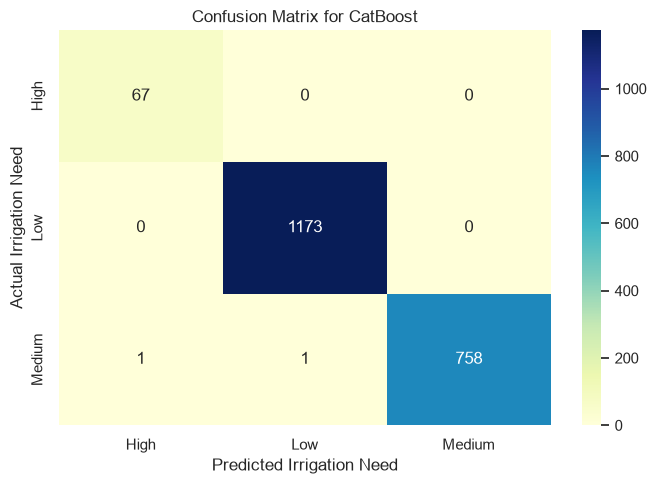

In [15]:
best_model_classes = best_irrigation_model.named_steps['classifier'].classes_
confusion_counts = confusion_matrix(test_labels, best_model_predictions, labels=best_model_classes)

plt.figure(figsize=(7, 5))
sns.heatmap(
    confusion_counts,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    xticklabels=best_model_classes,
    yticklabels=best_model_classes,
)
plt.title(f'Confusion Matrix for {best_model_name}')
plt.xlabel('Predicted Irrigation Need')
plt.ylabel('Actual Irrigation Need')
plt.tight_layout()
plt.show()

In [16]:
print(classification_report(test_labels, best_model_predictions, zero_division=0))

              precision    recall  f1-score   support

        High       0.99      1.00      0.99        67
         Low       1.00      1.00      1.00      1173
      Medium       1.00      1.00      1.00       760

    accuracy                           1.00      2000
   macro avg       0.99      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



## 10. Feature Importance

Use the best model's native importances when available. For linear models, use average absolute coefficients after preprocessing.

In [17]:
preprocessed_feature_names = best_irrigation_model.named_steps['preprocessor'].get_feature_names_out()
best_classifier = best_irrigation_model.named_steps['classifier']

if hasattr(best_classifier, 'feature_importances_'):
    importance_values = best_classifier.feature_importances_
elif hasattr(best_classifier, 'coef_'):
    importance_values = np.abs(best_classifier.coef_).mean(axis=0)
else:
    importance_values = np.zeros(len(preprocessed_feature_names))

feature_importance = (
    pd.DataFrame({
        'feature': preprocessed_feature_names,
        'importance': importance_values,
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

feature_importance.head(20)

,feature,importance
0,numeric__Soil_Moisture,20.709030
1,numeric__Rainfall_mm,16.702499
2,numeric__Temperature_C,12.402236
3,numeric__Wind_Speed_kmh,10.603898
4,categorical__Crop_Growth_Stage_Harvest,10.015110
5,categorical__Crop_Growth_Stage_Sowing,9.085921
6,categorical__Mulching_Used_No,8.079306
7,categorical__Mulching_Used_Yes,5.218887
8,categorical__Crop_Growth_Stage_Vegetative,2.380557
9,categorical__Crop_Growth_Stage_Flowering,2.160651


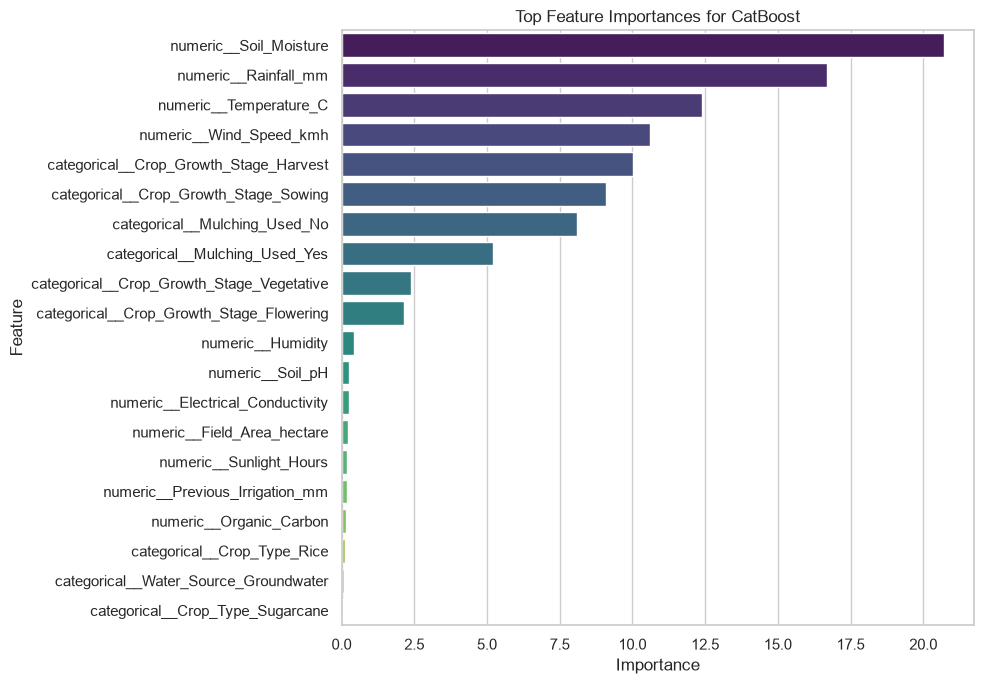

In [18]:
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 7))
sns.barplot(data=top_features, x='importance', y='feature', palette='viridis')
plt.title(f'Top Feature Importances for {best_model_name}')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 11. Example Irrigation Need Prediction

Use the selected model to predict irrigation need for one field profile.

In [19]:
example_field_profile = pd.DataFrame(
    [
        {
            'Soil_Type': 'Clay',
            'Soil_pH': 6.5,
            'Soil_Moisture': 28.0,
            'Organic_Carbon': 1.1,
            'Electrical_Conductivity': 1.2,
            'Temperature_C': 34.0,
            'Humidity': 45.0,
            'Rainfall_mm': 350.0,
            'Sunlight_Hours': 8.0,
            'Wind_Speed_kmh': 10.0,
            'Crop_Type': 'Wheat',
            'Crop_Growth_Stage': 'Vegetative',
            'Season': 'Rabi',
            'Irrigation_Type': 'Drip',
            'Water_Source': 'Reservoir',
            'Field_Area_hectare': 4.5,
            'Mulching_Used': 'Yes',
            'Previous_Irrigation_mm': 25.0,
            'Region': 'North',
        }
    ]
)

predicted_irrigation_need = best_irrigation_model.predict(example_field_profile)
print(f'Best model: {best_model_name}')
print(f'Predicted irrigation need: {predicted_irrigation_need[0]}')

Best model: CatBoost
Predicted irrigation need: ['Low']
